In [11]:
import yfinance as yf
import pandas as pd

# ETF ticker
ticker = "BOTZ"

# Proje önerisinde belirtildiği gibi 2016 sonundan 2024 başına kadar olan veriyi alıyoruz
botz = yf.Ticker(ticker)
data = botz.history(start="2016-09-01", end="2024-01-01")

# Sadece düzeltilmiş kapanış fiyatını al
df = data[["Close"]].copy()

# Kolon adını değiştir
df.columns = ["price"]

# Günlük değişimi hesapla
df["daily_return"] = df["price"].pct_change()

# İndeksi düzenle (.history() saat dilimi bilgisi ekler, onu temizliyoruz)
df.index = pd.to_datetime(df.index).tz_localize(None)
df.index.name = "date"
df = df.reset_index()

# İstenen sütunları seç ve boş satırları at
df = df[["date", "price", "daily_return"]]
df = df.dropna()

# Yuvarlama işlemi
df = df.round({"price": 5, "daily_return": 5})

# Kaydet
df.to_csv("botz_daily_data.csv", index=False)

print("Veri seti 2024 başına kadar filtrelenerek sorunsuz bir şekilde oluşturuldu!")
print(df.tail()) # Bitiş tarihlerinin doğru olduğunu teyit etmek için tail() kullanıyoruz

Veri seti 2024 başına kadar filtrelenerek sorunsuz bir şekilde oluşturuldu!
           date    price  daily_return
1832 2023-12-22 28.15547      -0.00386
1833 2023-12-26 28.37365       0.00775
1834 2023-12-27 28.45299       0.00280
1835 2023-12-28 28.48671       0.00119
1836 2023-12-29 28.26850      -0.00766


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1836 entries, 2016-09-14 to 2023-12-29
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         1836 non-null   float64
 1   daily_return  1836 non-null   float64
dtypes: float64(2)
memory usage: 43.0 KB


In [14]:
import pandas as pd

# Veriyi yükle (Tarih sütununu datetime formatında okuyup index yapıyoruz)
df = pd.read_csv("botz_daily_data.csv", index_col="date", parse_dates=True)

# 1. Pandas'ın varsayılan özet istatistiklerini hesapla 
# (count, mean, std, min, 25%, 50%, 75%, max içerir)
summary_stats = df.describe()

# 2. Varsayılan tabloda Varyans (Variance) bulunmaz, onu ayrıca hesaplayıp tabloya ekleyelim
summary_stats.loc['variance'] = df.var()

# Çıktının okunabilirliğini artırmak için formatı ayarlayalım (Virgülden sonra 5 basamak)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

print("--- BOTZ ETF Günlük Veri Seti Temel İstatistiksel Özeti ---")
print(summary_stats)

--- BOTZ ETF Günlük Veri Seti Temel İstatistiksel Özeti ---
              price  daily_return
count    1836.00000    1836.00000
mean       23.62492       0.00051
std         5.92508       0.01630
min        14.11348      -0.12406
25%        19.42578      -0.00709
50%        22.27611       0.00093
75%        26.72868       0.00952
max        39.33899       0.12771
variance   35.10653       0.00027


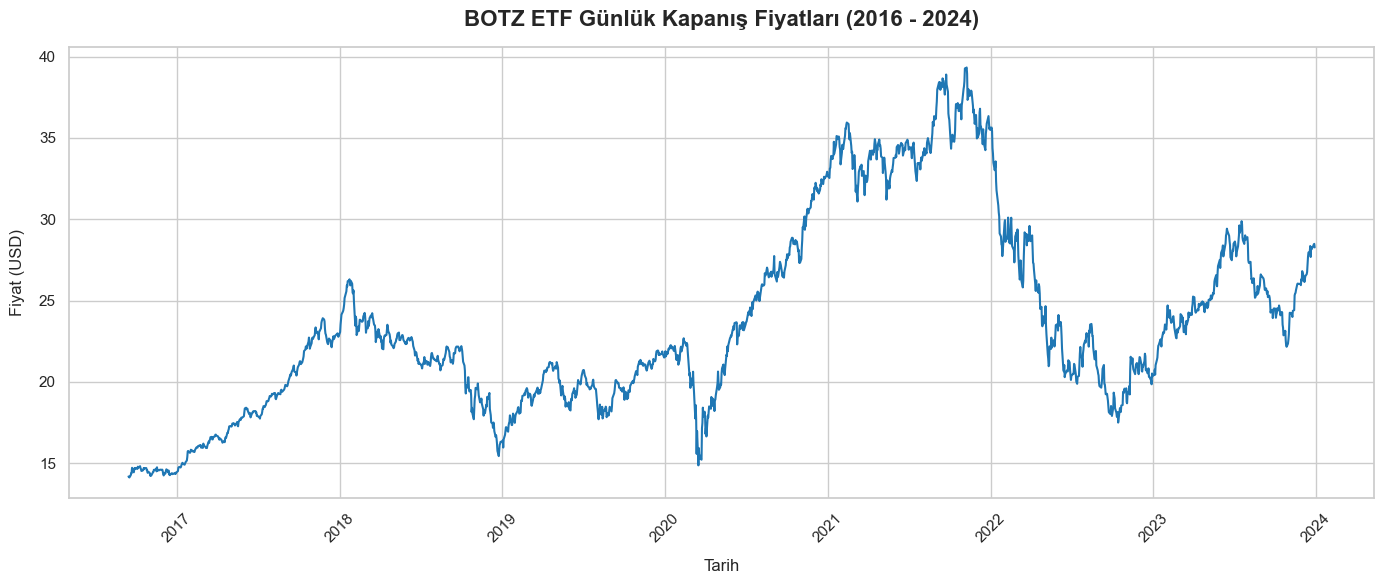

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yükle ve date sütununu datetime formatında algıla
df = pd.read_csv("botz_daily_data.csv", parse_dates=["date"])

# Görselleştirme teması ayarları (Raporlar için temiz bir arka plan)
sns.set_theme(style="whitegrid")

# Grafik boyutunu belirle
plt.figure(figsize=(14, 6))

# Çizgi grafiğini (Line plot) oluştur
sns.lineplot(data=df, x="date", y="price", color="#1f77b4", linewidth=1.5)

# Başlık ve eksen etiketlerini ayarla
plt.title("BOTZ ETF Günlük Kapanış Fiyatları (2016 - 2024)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Tarih", fontsize=12, labelpad=10)
plt.ylabel("Fiyat (USD)", fontsize=12, labelpad=10)

# X eksenindeki tarihlerin daha okunaklı olması için döndür
plt.xticks(rotation=45)

# Kenar boşluklarını otomatik ayarla
plt.tight_layout()

# Grafiği göster (veya plt.savefig("botz_price_plot.png") ile kaydet)
plt.show()

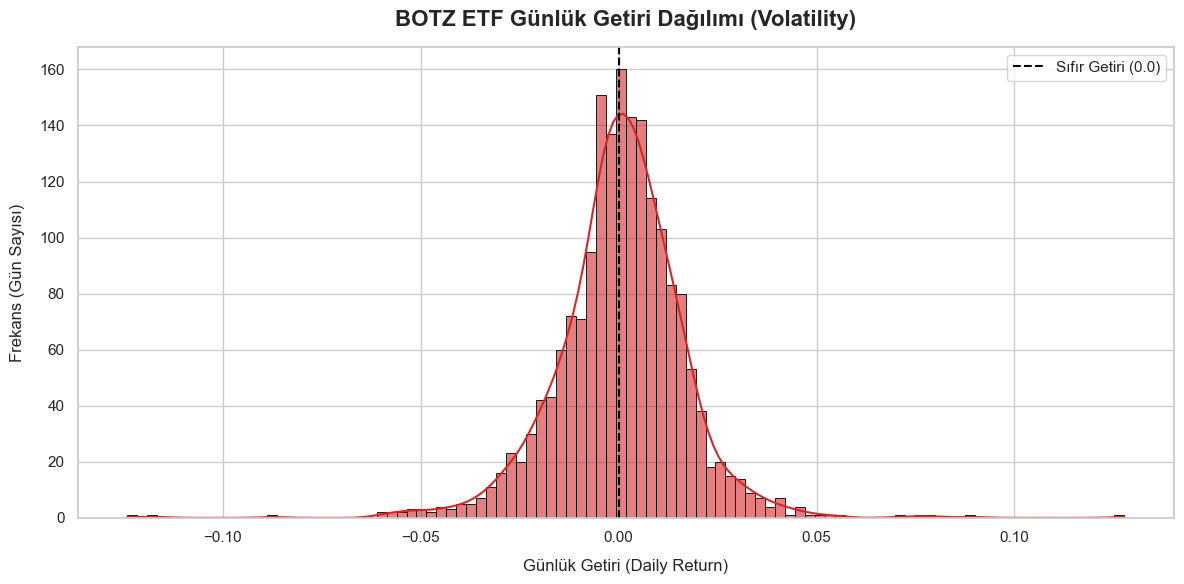

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yükle
df = pd.read_csv("botz_daily_data.csv")

# Görselleştirme teması
sns.set_theme(style="whitegrid")

# Grafik boyutunu belirle
plt.figure(figsize=(12, 6))

# Histogram ve KDE (Yoğunluk Eğrisi) çizimi
# bins=100 parametresi çubuk sayısını artırarak daha detaylı bir görünüm sağlar
sns.histplot(data=df, x="daily_return", bins=100, kde=True, color="#d62728", edgecolor="black", alpha=0.6)

# Getirinin tam 0 olduğu noktaya dikey, kesik bir referans çizgisi ekle
plt.axvline(x=0, color="black", linestyle="--", linewidth=1.5, label="Sıfır Getiri (0.0)")

# Başlık ve eksen etiketlerini ayarla
plt.title("BOTZ ETF Günlük Getiri Dağılımı (Volatility)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Günlük Getiri (Daily Return)", fontsize=12, labelpad=10)
plt.ylabel("Frekans (Gün Sayısı)", fontsize=12, labelpad=10)

# Legend (Gösterge) ekle
plt.legend()

# Kenar boşluklarını otomatik ayarla
plt.tight_layout()

# Grafiği göster
plt.show()